In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

# Feature Extraction Pipeline for TJU DHD

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

patch_types = [
    'Naturalistic1', 'Naturalistic2', 'Naturalistic3',
    'Naturalistic4', 'Naturalistic5', 'Naturalistic6',
    'TSEA1', 'TSEA2'
]

train = pd.read_csv("features_Train_nogabor.csv")
test  = {patch: pd.read_csv(f"features_{patch}_Test_nogabor.csv") for patch in patch_types}

drop_cols = ['image_name', 'region_id', 'adversarial']
X_train = train.drop(columns=drop_cols)
y_train = train['adversarial'].astype(int)

X_test = {}
y_test = {}

for patch in patch_types:
    X_test[patch] = test[patch].drop(columns=drop_cols)
    y_test[patch] = test[patch]['adversarial'].astype(int)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

for patch in patch_types:
    X_test[patch] = scaler.transform(X_test[patch])

def evaluate(model, X, y, name, patch):
    y_pred = model.predict(X)
    return {
        f"{name}_{patch}_Accuracy":  accuracy_score(y, y_pred),
        f"{name}_{patch}_Precision": precision_score(y, y_pred),
        f"{name}_{patch}_Recall":    recall_score(y, y_pred),
        f"{name}_{patch}_F1":        f1_score(y, y_pred)
    }

results = {}

# 4) Train and validate models with some hyperparameters
# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
for patch in patch_types:
    results.update(evaluate(logreg, X_test[patch], y_test[patch], "LogReg", patch))

# Random Forest (try different n_estimators on val set)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
for patch in patch_types:
    results.update(evaluate(rf, X_test[patch], y_test[patch], "RF", patch))

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=5, 
    learning_rate=0.1, 
    use_label_encoder=False, 
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
for patch in patch_types:
    results.update(evaluate(xgb_model, X_test[patch], y_test[patch], "XGB", patch))

# KNN (e.g., k=5 tuned via val set)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
for patch in patch_types:
    results.update(evaluate(knn, X_test[patch], y_test[patch], "KNN", patch))

# 5) Print results
for k,v in results.items():
    print(f"{k}: {v:.4f}")


C:\Adrianov\Projects\Project-Satanael\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:57:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


LogReg_Naturalistic1_Accuracy: 0.9825
LogReg_Naturalistic1_Precision: 0.9388
LogReg_Naturalistic1_Recall: 1.0000
LogReg_Naturalistic1_F1: 0.9684
LogReg_Naturalistic2_Accuracy: 0.9925
LogReg_Naturalistic2_Precision: 0.9848
LogReg_Naturalistic2_Recall: 1.0000
LogReg_Naturalistic2_F1: 0.9924
LogReg_Naturalistic3_Accuracy: 0.9834
LogReg_Naturalistic3_Precision: 0.9375
LogReg_Naturalistic3_Recall: 1.0000
LogReg_Naturalistic3_F1: 0.9677
LogReg_Naturalistic4_Accuracy: 0.9861
LogReg_Naturalistic4_Precision: 0.9808
LogReg_Naturalistic4_Recall: 0.9808
LogReg_Naturalistic4_F1: 0.9808
LogReg_Naturalistic5_Accuracy: 0.9771
LogReg_Naturalistic5_Precision: 0.9247
LogReg_Naturalistic5_Recall: 1.0000
LogReg_Naturalistic5_F1: 0.9609
LogReg_Naturalistic6_Accuracy: 0.9707
LogReg_Naturalistic6_Precision: 0.9326
LogReg_Naturalistic6_Recall: 0.9881
LogReg_Naturalistic6_F1: 0.9595
LogReg_TSEA1_Accuracy: 1.0000
LogReg_TSEA1_Precision: 1.0000
LogReg_TSEA1_Recall: 1.0000
LogReg_TSEA1_F1: 1.0000
LogReg_TSEA2_Accu

In [4]:
test  = {patch: pd.read_csv(f"features_{patch}_Test_nogabor.csv") for patch in patch_types}

drop_cols = ['image_name', 'region_id', 'adversarial']

X_test = {}
y_test = {}

for patch in patch_types:
    X_test[patch] = test[patch].drop(columns=drop_cols)
    y_test[patch] = test[patch]['adversarial'].astype(int)

merged_blocks = []
for patch in patch_types:
    # Make a copy of features for safety
    block = X_test[patch].copy()
    
    # Attach label and optionally patch info
    block['adversarial'] = y_test[patch].values
    merged_blocks.append(block)

# Merge into one DataFrame
merged_df = pd.concat(merged_blocks, ignore_index=True)

# Split features and labels again if needed
X_test_merged = merged_df.drop(columns=['adversarial'])
y_test_merged = merged_df['adversarial']

X_test_merged = scaler.transform(X_test_merged)

results.update(evaluate(logreg, X_test_merged, y_test_merged, "LogReg", 'Overall'))
results.update(evaluate(rf, X_test_merged, y_test_merged, "RF", 'Overall'))
results.update(evaluate(xgb_model, X_test_merged, y_test_merged, "XGB", 'Overall'))
results.update(evaluate(knn, X_test_merged, y_test_merged, "KNN", 'Overall'))

for k,v in results.items():
    print(f"{k}: {v:.4f}")

LogReg_Naturalistic1_Accuracy: 0.9825
LogReg_Naturalistic1_Precision: 0.9388
LogReg_Naturalistic1_Recall: 1.0000
LogReg_Naturalistic1_F1: 0.9684
LogReg_Naturalistic2_Accuracy: 0.9925
LogReg_Naturalistic2_Precision: 0.9848
LogReg_Naturalistic2_Recall: 1.0000
LogReg_Naturalistic2_F1: 0.9924
LogReg_Naturalistic3_Accuracy: 0.9834
LogReg_Naturalistic3_Precision: 0.9375
LogReg_Naturalistic3_Recall: 1.0000
LogReg_Naturalistic3_F1: 0.9677
LogReg_Naturalistic4_Accuracy: 0.9861
LogReg_Naturalistic4_Precision: 0.9808
LogReg_Naturalistic4_Recall: 0.9808
LogReg_Naturalistic4_F1: 0.9808
LogReg_Naturalistic5_Accuracy: 0.9771
LogReg_Naturalistic5_Precision: 0.9247
LogReg_Naturalistic5_Recall: 1.0000
LogReg_Naturalistic5_F1: 0.9609
LogReg_Naturalistic6_Accuracy: 0.9707
LogReg_Naturalistic6_Precision: 0.9326
LogReg_Naturalistic6_Recall: 0.9881
LogReg_Naturalistic6_F1: 0.9595
LogReg_TSEA1_Accuracy: 1.0000
LogReg_TSEA1_Precision: 1.0000
LogReg_TSEA1_Recall: 1.0000
LogReg_TSEA1_F1: 1.0000
LogReg_TSEA2_Accu

### Save the model

In [5]:
import joblib

# --- Save models ---

# Save the scaler using joblib
joblib.dump(scaler, "minmax_scaler.pkl")

# Save Random Forest using joblib
joblib.dump(rf, "random_forest_model.pkl")

# Save XGBoost using its native save_model
xgb_model.save_model("xgboost_model.json")

# Optionally also save using joblib (scikit-learn compatible format)
joblib.dump(xgb_model, "xgboost_model.pkl")


# --- Load models later for inference ---
# Load Random Forest
rf_loaded = joblib.load("random_forest_model.pkl")

# Load XGBoost (native way)
xgb_loaded = xgb.XGBClassifier()
xgb_loaded.load_model("xgboost_model.json")

scaler = joblib.load("minmax_scaler.pkl")
# Test inference
sample_preds_rf = rf_loaded.predict(X_test_merged)
sample_preds_xgb = xgb_loaded.predict(X_test_merged)

print(sample_preds_rf)

[0 0 0 ... 1 1 1]


In [5]:
import time
start = time.time()
# Load XGBoost (native way)
xgb_loaded = xgb.XGBClassifier()
xgb_loaded.load_model("xgboost_model.json")

# Test inference
sample_preds_rf = rf_loaded.predict(X_test)
sample_preds_xgb = xgb_loaded.predict(X_test)
elapsed = time.time() - start

print(f"Inference completed, {elapsed:.2f} seconds elapsed.")

Inference completed, 0.38 seconds elapsed.


### Feature significance

In [6]:
feature_names = train.drop(columns=['image_name', 'region_id', 'adversarial']).columns
booster = xgb_model.get_booster()
importance = booster.get_score(importance_type='gain')

# Map back to original feature names
importance_df = pd.DataFrame({
    'Feature': [feature_names[int(k[1:])] for k in importance.keys()],
    'Importance': importance.values()
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(20))

                     Feature  Importance
25                rgb_G_bin0  234.619980
159                hsv_S_std  208.882477
26                rgb_G_bin1   61.384937
158               hsv_S_mean   22.575788
2                 rgb_R_bin1   19.970896
54                rgb_B_bin8   18.697172
78                hsv_H_bin7   17.111179
1                 rgb_R_bin0   11.340806
168      contrast_dist2_0deg   11.234807
164      contrast_dist1_0deg    9.597840
107               hsv_S_bin6    8.650784
41               rgb_G_bin19    6.569673
186  homogeneity_dist32_0deg    6.341528
182   homogeneity_dist1_0deg    6.287716
111              hsv_S_bin11    5.738482
94               hsv_H_bin23    4.991421
191       energy_dist64_0deg    4.898409
161               hsv_V_mean    4.747833
124              hsv_S_bin30    4.707469
7                 rgb_R_bin6    4.666843


C:\Users\adria\AppData\Local\Temp\ipykernel_40500\3277945209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


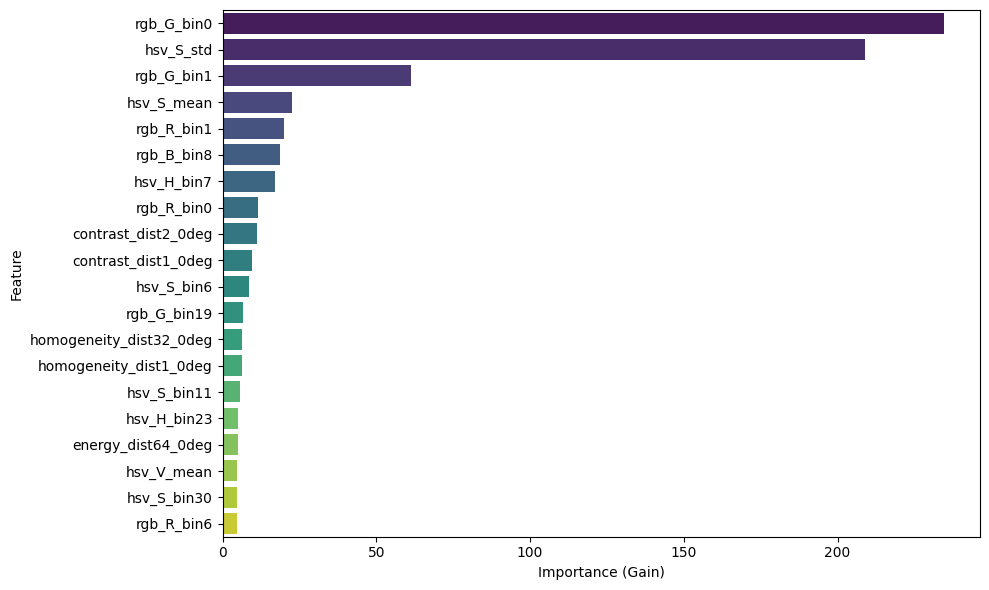

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=importance_df.head(20),
    palette="viridis"
)
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

         Feature  Importance
206    hsv_S_std    0.071025
161   hsv_V_bin0    0.060935
162   hsv_V_bin1    0.054971
34    rgb_G_bin1    0.051560
159  hsv_S_bin30    0.050836
158  hsv_S_bin29    0.044025
1     rgb_R_bin0    0.042495
33    rgb_G_bin0    0.036769
156  hsv_S_bin27    0.035878
163   hsv_V_bin2    0.031934
65    rgb_B_bin0    0.030704
160  hsv_S_bin31    0.027752
66    rgb_B_bin1    0.026562
2     rgb_R_bin1    0.026238
35    rgb_G_bin2    0.025742
157  hsv_S_bin28    0.024429
3     rgb_R_bin2    0.023327
154  hsv_S_bin25    0.022448
155  hsv_S_bin26    0.018604
205   hsv_S_mean    0.018007


C:\Users\adria\AppData\Local\Temp\ipykernel_40500\1721199451.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


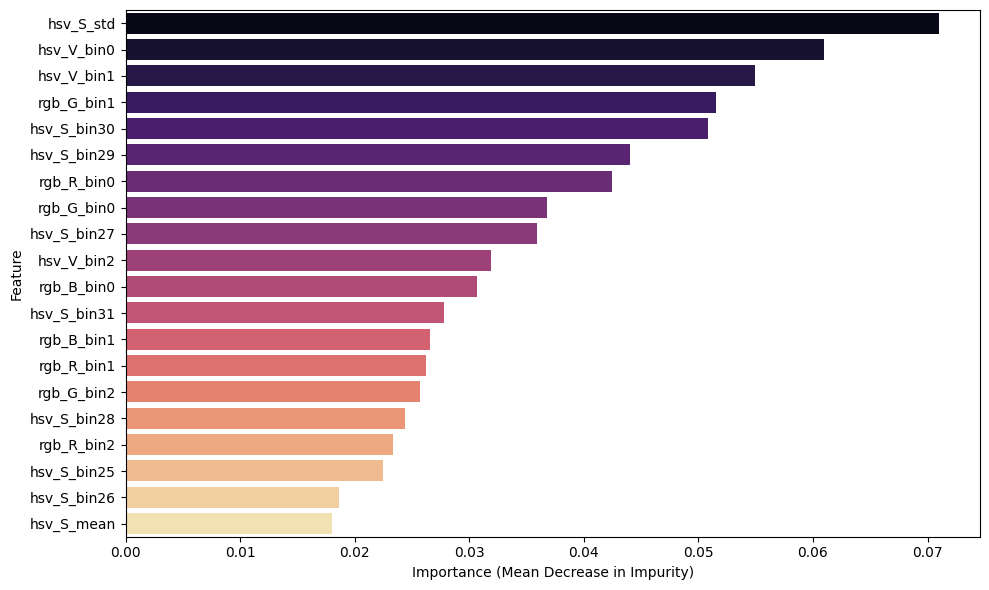

In [21]:
rf_importance = pd.DataFrame({
    'Feature': feature_names,   # same feature_names as before
    'Importance': rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importance.head(20))

# Plot top 20
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance.head(20),
    palette="magma"
)
plt.xlabel("Importance (Mean Decrease in Impurity)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()